# Demo of the latent sampling in StyleGAN2

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from tqdm.auto import tqdm

from dataclasses import dataclass
import pickle

import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device

In [3]:
SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

OUT_DIR = Path('out')

device = get_device()
print(device)

mps


In [4]:
def prediction_to_img(pred: torch.Tensor) -> np.ndarray:
    img = pred[0].permute(1, 2, 0)
    np_img = img.cpu().numpy()

    mini = np_img.min(axis=(0, 1), keepdims=True)
    maxi = np_img.max(axis=(0, 1), keepdims=True)
    np_img = (np_img - mini) / (maxi - mini)

    return np_img

In [7]:
with open('models/ffhq.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)


/var/folders/pc/hcpfk3hd2_qbyhc3695l5gfw0000gn/T/ipykernel_84385/3389835213.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  G = pickle.load(f)['G_ema'].to(device)


## Sampling in the $\mathcal{Z}$ latent space

In [6]:
z = torch.randn([1, G.z_dim]).to(device)
w = G.mapping(z, None)
pred = G.synthesis(w)

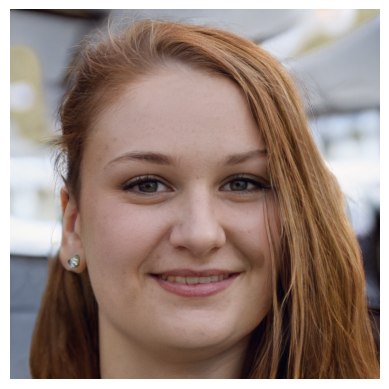

In [8]:
img = prediction_to_img(pred)

_ = plt.imshow(img)
_ = plt.axis('off')
_ = plt.show()

## Interpolation in the $\mathcal{Z}$ latent space

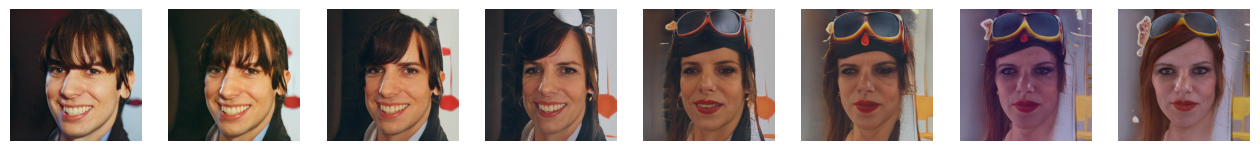

In [9]:
N_INTERPOLATION = 8

z1 = torch.randn([1, G.z_dim]).to(device)
z2 = torch.randn([1, G.z_dim]).to(device)

_ = plt.figure(figsize=(2*N_INTERPOLATION, 2))
for i in range(N_INTERPOLATION):
    t = i / (N_INTERPOLATION-1)
    z = (1 - t) * z1 + t * z2

    with torch.no_grad():
        w = G.mapping(z, None)
        pred = G.synthesis(w)

    ax = plt.subplot(1, N_INTERPOLATION, i+1)
    _ = ax.imshow(prediction_to_img(pred))
    ax.set_axis_off()

_ = plt.show()

## Interpolation in the $\mathcal{W}$ latent space

In [ ]:
N_INTERPOLATION = 8

w1 = G.mapping(z1, None)
w2 = G.mapping(z2, None)

_ = plt.figure(figsize=(2*N_INTERPOLATION, 2))
for i in range(N_INTERPOLATION):
    t = i / (N_INTERPOLATION-1)
    w = (1 - t) * w1 + t * w2

    with torch.no_grad():
        pred = G.synthesis(w)

    ax = plt.subplot(1, N_INTERPOLATION, i+1)
    _ = ax.imshow(prediction_to_img(pred))
    ax.set_axis_off()

_ = plt.show()